In [ ]:
%matplotlib inline


# Réseaux récurrents pour la classification de texte
D'après le tutoriel de
**Author**: [Sean Robertson](https://github.com/spro/practical-pytorch)

Reformulé pour le Master SID Université de Rouen Normandie, module Deep Learning, Thierry Paquet, 2023.

Nous construisons un réseau récurrent chargé de classer l'origine des noms de famille. Le dataset est constitué d'un ensemble de noms de famille Européens. Le réseau parcourt un nom de gauche à droite, caractère par caractère, et utilise son état interne à la fin du parcours pour classer le nom parmi 18 langues possibles.
Voici deux exemples de prédiction:
    
    $ python predict.py Hinton
    (-0.47) Scottish
    (-1.52) English
    (-3.57) Irish

    $ python predict.py Schmidhuber
    (-0.19) German
    (-2.48) Czech
    (-2.68) Dutch


## Preparation des données

Le fichier de prénoms est chargé à partir de ce lien
   [https://download.pytorch.org/tutorial/data.zip](https://download.pytorch.org/tutorial/data.zip) et décompressé dans le répertoire courant.

Dans le répertoire ``data/names`` se trouvent 18 fichiers texte nommés
"[Language].txt". Chaque fichier comprend un ensemble de noms, un par ligne, écrits avec des caractères Romains. Mais il subsiste des caractères spéciaux propres à certaines langues, que l'on va devoir normaliser. Une étape de pré-traitement est donc mise en oeuvre pour transformer les caractères UNICODE en ASCII.

Depuis votre machine locale, placer les 18 fichiers dans un répertoire ``data/names`` sous google drive. A l'intialisation de votre programme, vous crérez le répertoire drive puis monterez votre partition Drive dans votre environnement d'exécution Colab à l'aide des commandes ci-dessous.

## **Question 1:** Expliquez chaque étape de la méthode ```unicodeToAscii()```**

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    The function removes accents by decomposing characters into base letters + diacritics. It deletes diacritics using unicodedata.category(c) != 'Mn' and ensures only ASCII characters remain using c in all_letters. Finally, it joins all letters to return a cleaned ASCII string.
  </p>
  <ul>
    <li>Input: 'Ślusàrski'</li>
    <li>Step 1 (Normalize): 'Ślus`arski'</li>
    <li>Step 2 (Remove Diacritics): 'Slus arski'</li>
    <li>Step 3 (Keep Allowed Characters): 'Slusarski'</li>
    <li>Output: 'Slusarski'</li>
  </ul>
</div>

In [2]:
# from google.colab import drive
# !mkdir -p drive
# drive.mount('/content/drive',force_remount=True)
# #!ls drive/MyDrive/data/names

In [11]:
from __future__ import unicode_literals, print_function, division
from io import open
import glob
import os
import unicodedata
import string

def findFiles(path): return glob.glob(path)

all_letters = string.ascii_letters + " .,;'"
n_letters = len(all_letters)

# Turn a Unicode string to plain ASCII, thanks to https://stackoverflow.com/a/518232/2809427
def unicodeToAscii(s):
    return ''.join( # constructs the final string
        c for c in unicodedata.normalize('NFD', s) # split the letter and the accent
        if unicodedata.category(c) != 'Mn' # Remove diacritics (accents)
        and c in all_letters # keep the Ascii letters
    )
    # In NFD, characters with diacritics are split into their base letter and the accent mark.
    # 'Mn' stands for "Mark, Nonspacing" → These are diacritics (accents).

print('Ślusàrski ToAscii',unicodeToAscii('Ślusàrski'))

# Build the category_lines dictionary, a list of names per language
category_lines = {}
all_categories = []

# Read a file and split into lines
def readLines(filename):
    lines = open(filename, encoding='utf-8').read().strip().split('\n')
    return [unicodeToAscii(line) for line in lines]

for filename in findFiles('data/names/*.txt'):
    category = os.path.splitext(os.path.basename(filename))[0]
    all_categories.append(category)
    lines = readLines(filename)
    category_lines[category] = lines

n_categories = len(all_categories)

Ślusàrski ToAscii Slusarski


A present nous avons dans la variable ``category_lines``,  un dictionnaire des noms des langues qui permet d'accéder au listes de noms de chaque langue. On mémorise également dans la variable  ``all_categories`` la liste des noms des langues et dans ``n_categories`` le nombre de langues.




In [12]:
print(category_lines['Italian'][:5])

['Abandonato', 'Abatangelo', 'Abatantuono', 'Abate', 'Abategiovanni']


### Transformation en tenseurs

Il faut maintenant écrire les données dans des tenseurs. Chaque caractère va être encodé en un vecteur binaire dit "one-hot vector" de taille
$<1 \times n_{letters}>$. Un vecteur one-hot est un vecteur binaire rempli de valeurs à 0 à l'exception d'une seule entrée mise à 1 correspondant à l'index du caractère représenté par ce vecteur, par exemple ``"b" = <0 1 0 0 0 ...>``.

Un mot est donc encodé par une séquence de vecteurs one-hot qui est placée dans un tenseur 2D de dimension $<line\_length \times 1 \times n_{letters}>$.

On insère une dimension suplémentaire de taille 1 parce que PyTorch manipule des lots (batch) - ici nous avons donc un batch de taille 1 exemple.


In [13]:
import torch

# Find letter index from all_letters, e.g. "a" = 0
def letterToIndex(letter):
    return all_letters.find(letter)

# Just for demonstration, turn a letter into a <1 x n_letters> Tensor
def letterToTensor(letter):
    tensor = torch.zeros(1, n_letters)
    tensor[0][letterToIndex(letter)] = 1
    return tensor

# Turn a line into a <line_length x 1 x n_letters>,
# or an array of one-hot letter vectors
def lineToTensor(line):
    tensor = torch.zeros(len(line), 1, n_letters)
    for li, letter in enumerate(line):
        tensor[li][0][letterToIndex(letter)] = 1
    return tensor
print('One hot vector de la lettre J:')
print(letterToTensor('J'))

print('Taille du tenseur encodant le mot "Jones":')
print(lineToTensor('Jones').size())

One hot vector de la lettre J:
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0.]])
Taille du tenseur encodant le mot "Jones":
torch.Size([5, 1, 57])


In [ ]:
print(all_letters)

abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ .,;'


## Creation de la classe réseau récurrent
Avant l'utilisation par Pytorch de l'autodifférentiation par la méthode  ``` autograd```, la création d'un réseau récurrent passait par la déclaration d'une couche qui se répétait sur plusieurs pas de temps consécutifs. Ces couches maintenaient l'état caché et le gradient rétropropagé au cours du temps.

Désormais, les couches récurrentes sont gérées par ```autograd``` qui construit pour nous le graphe de calcul du réseau déplié au cours du temps. Cela veut dire qu'un réseau récurrent est désormais déclaré comme un réseau feed-forward non récurrent, et que c'est autograd qui gère la structure récurrente lorsque le réseaux est instancié.

Le réseau récurrent que nous allons utiliser contient simplement deux couches `Linear()` qui voient toutes deux les données d'entrée constituées de l'entrée courante + la sortie précédente concaténées ```combined = torch.cat()```.

La première couche linéaire est de type feedforward suivie d'une activation softmax. Elle produit la sortie courante.
La seconde couche est récurrente. Elle produit l'état caché de la couche récurrente à travers une couche linéaire. L'ensemble est schématisé sur cette figure: <img src="https://i.imgur.com/Z2xbySO.png"></img>


In [14]:
import torch.nn as nn

class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()

        self.hidden_size = hidden_size

        self.i2h = nn.Linear(input_size + hidden_size, hidden_size)
        self.i2o = nn.Linear(input_size + hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden):
        combined = torch.cat((input, hidden), 1)
        hidden = self.i2h(combined)
        output = self.i2o(combined)
        output = self.softmax(output)
        return output, hidden

    def initHidden(self):
        return torch.zeros(1, self.hidden_size)

n_hidden = 128
rnn = RNN(n_letters, n_hidden, n_categories)

Pour faire une itération avec ce réseau il faut lui fournir une entrée (dans notre cas le one-hot vector qui encode le caractère courant et l'état précédent du réseau (initialisé à zéro à la première itération).
Le réseau fournit en retour le vecteur de probabilité de chaque langue et l'état caché courant (que l'on va utiliser pour l'itération suivante).

In [15]:
input = letterToTensor('A')
hidden = torch.zeros(1, n_hidden)

output, next_hidden = rnn(input, hidden)

In [16]:
print(output)

tensor([[-2.9483, -2.9077, -2.9154, -2.8013, -2.9463, -2.9409, -2.8212, -2.8974,
         -2.7757, -2.8528, -2.9822, -2.8115, -2.9047, -2.8824, -2.8999, -2.9140,
         -2.9565, -2.8975]], grad_fn=<LogSoftmaxBackward0>)


Pour être plus efficace on ne crée pas un nouveau tenseur pour chaque nouveau caractère d'entrée.
A la place, on crée un seul tenseur pour toute la séquence de caractères. On utilise  `` input = lineToTensor`` au lieu de ``letterToTensor`` et on itère sur toutes les positions du tenseur de la séquence d'entrée.

## **Question 2:** Expliquez chaque étape de la méthode ```lineToTensor()```

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    The function converts each letter of a string into a one-hot encoded vector and stacks them into a tensor. len(line) represents the number of letters in the input string and n_letters is the total number of possible characters (size of the one-hot vector).
  </p>
  <ul>
    <li>Input: 'Ślusàrski'</li>
    <li>Step 1 : Creates a tensor of shape (line_length, 1, n_letters)</li>
    <li>Step 2 : One-hot encodes each letter'</li>
    <li>Step 3 : Returns a stacked tensor representing the full word</li>
    <li>Output: 'Slusarski'</li>
  </ul>
</div>

## **Question 3:** Que représente le tenseur ```output``` ?

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    Output is the tensor with the probabilities of input belonging to each language. It is the current output.
  </p>
</div>

In [17]:
input = lineToTensor('Albert')
hidden = torch.zeros(1, n_hidden)

output, next_hidden = rnn(input[0], hidden)
# print(output)

In [18]:
print(output)

tensor([[-2.9483, -2.9077, -2.9154, -2.8013, -2.9463, -2.9409, -2.8212, -2.8974,
         -2.7757, -2.8528, -2.9822, -2.8115, -2.9047, -2.8824, -2.8999, -2.9140,
         -2.9565, -2.8975]], grad_fn=<LogSoftmaxBackward0>)


In [19]:
print(output.topk(1))

torch.return_types.topk(
values=tensor([[-2.7757]], grad_fn=<TopkBackward0>),
indices=tensor([[8]]))


In [20]:
top_n, top_i = output.topk(1)
category_i = top_i[0].item()
print(top_n)
print(top_i)
print(category_i)

tensor([[-2.7757]], grad_fn=<TopkBackward0>)
tensor([[8]])
8


## Entrainement du réseau
Préparer l'entrainement
----------------------

On déclare quelques fonctions qui vont nous aider. La première va nous permettre de mieux visualiser la sortie courante du réseau. On utilise pour cela la méthode ``categoryFromOutput()``.

## **Question 4:** Expliquez chaque ligne de la méthode ``categoryFromOutput()``

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    The function receives a output and classifies it as the category with highest probability.
  </p>
  <ul>
    <li>Line 1 : Gets the highest probability and its id</li>
    <li>Line 2 : Gets the id value</li>
    <li>Line 3 : Returns the category name and id</li>
  </ul>
</div>

In [21]:
def categoryFromOutput(output):
    top_n, top_i = output.topk(1) # gets the highest probamatrixbility and its id
    category_i = top_i[0].item() # gets the id value
    return all_categories[category_i], category_i # returns the category name and id

# print(categoryFromOutput(output))

In [22]:
print(categoryFromOutput(output))

('Irish', 8)


On a également besoin de visualiser un exemple d'apprentissage (un nom et sa langue).

## **Question 5:** Que réalise la fonction ``` randomTrainingExample()``` ?
<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    It chooses a random category and them a random name from that same category.
</div>


In [23]:
import random

def randomChoice(l):
    return l[random.randint(0, len(l) - 1)]

def randomTrainingExample():
    category = randomChoice(all_categories)
    line = randomChoice(category_lines[category])
    category_tensor = torch.tensor([all_categories.index(category)], dtype=torch.long)
    line_tensor = lineToTensor(line)
    return category, line, category_tensor, line_tensor

for i in range(10):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    # print('category =', category, '/ line =', line)

In [24]:
print('category =', category, '/ line =', line)

category = Vietnamese / line = Kim


### Entrainer le réseau

Maintenant il suffit de présenter au réseau un lot d'apprentissage pour qu'il fasse une prédiction et qu'il adapte ses poids en fonction de ses erreurs.
Puisque la fonction d'activation de sortie est une `nn.LogSoftmax`, le critère d'apprentissage choisi est  `nn.NLLLoss`.


## **Question 6:** A quoi correspond le critère pytorch `nn.NLLLoss` ?

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    It is the negative log likelihood loss, that is, the Loss is calculated with a input that contains log-probabilities of each class.
</div>


In [25]:
criterion = nn.NLLLoss()

Chaque époque de la boucle d'apprentissage fait appel à la méthode `train()`

## **Question 7:** expliquez toutes les étapes de la méthode `train()`
Préciser
- la taille des lots
- l'optimiseur utilisé

Proposez quelques améliorations possibles de cette méthode

In [26]:
learning_rate = 0.005 # If you set this too high, it might explode. If too low, it might not learn

def train(category_tensor, line_tensor):
    hidden = rnn.initHidden() # initializes an empity hidden memory

    rnn.zero_grad() # initializes the gradients as zeros

    for i in range(line_tensor.size()[0]): # for each letter of the name
        output, hidden = rnn(line_tensor[i], hidden) # send one letter at a time keeping a short memory until the name is finished

    loss = criterion(output, category_tensor) # calculates the loss after the whole name has been treated
    loss.backward() # apply the retropropagation

    # Add parameters' gradients to their values, multiplied by learning rate
    for p in rnn.parameters(): # for each parameter
        p.data.add_(p.grad.data, alpha=-learning_rate) # update the parameter with a step

    return output, loss.item() # returns the calculated probabilities and the Loss value

Maintenant il suffit simplement de lancer l'exécution de l'apprentissage sur l'ensemble des exemples.

## **Question 8 :** expliquer la structure de la boucle principale du programme
Précisez notamment les variables mémorisées et visualisées

In [27]:
import time
import math

n_iters = 100000
print_every = 5000
plot_every = 1000


# Keep track of losses for plotting
current_loss = 0
all_losses = []

def timeSince(since):
    now = time.time()
    s = now - since
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

start = time.time()

for iter in range(1, n_iters + 1): # loops for i_iter times
    category, line, category_tensor, line_tensor = randomTrainingExample() # selects a random exemple for training
    output, loss = train(category_tensor, line_tensor) # train on that example
    current_loss += loss # updates the loss

    # Print iter number, loss, name and guess periodicaly
    if iter % print_every == 0:
        guess, guess_i = categoryFromOutput(output)
        correct = '✓' if guess == category else '✗ (%s)' % category
        print('%d %d%% (%s) %.4f %s / %s %s' % (iter, iter / n_iters * 100, timeSince(start), loss, line, guess, correct))

    # Add current loss avg to list of losses periodicaly
    if iter % plot_every == 0:
        all_losses.append(current_loss / plot_every)
        current_loss = 0

/usr/local/lib/python3.10/dist-packages/torch/autograd/graph.py:768: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


5000 5% (2m 25s) 2.5030 Addison / Scottish ✗ (English)
10000 10% (2m 39s) 1.8053 Mateus / Portuguese ✓
15000 15% (2m 52s) 2.4584 Ichiyusai / Polish ✗ (Japanese)
20000 20% (3m 9s) 2.4783 Sarna / Spanish ✗ (Czech)
25000 25% (3m 26s) 1.8947 Kwak / Chinese ✗ (Korean)
30000 30% (3m 38s) 1.6982 Bran / Irish ✓
35000 35% (3m 51s) 0.8966 Luc / Vietnamese ✓
40000 40% (4m 8s) 3.0718 Banks / Czech ✗ (English)
45000 45% (4m 30s) 3.4779 Strohkirch / Czech ✗ (German)
50000 50% (4m 44s) 0.7923 Martinez / Spanish ✓
55000 55% (5m 0s) 2.1274 Dingle / Irish ✗ (English)
60000 60% (5m 19s) 1.7434 Middelburg / English ✗ (Dutch)
65000 65% (5m 37s) 1.4525 Chu / Vietnamese ✗ (Korean)
70000 70% (5m 50s) 1.2413 Zabala / Spanish ✓
75000 75% (6m 10s) 1.0136 Henderson / Scottish ✓
80000 80% (6m 24s) 0.0256 Nakagawa / Japanese ✓
85000 85% (6m 42s) 2.8109 Fashingbauer / Arabic ✗ (German)
90000 90% (7m 1s) 0.0954 Duong / Vietnamese ✓
95000 95% (7m 17s) 1.6364 Segers / Portuguese ✗ (Dutch)
100000 100% (7m 29s) 3.1929 Pu

### Affichage des résultats

On visualise l'évolution du critère ``all_losses`` au cours de l'apprentissage:


/home/UR/coelhrod/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


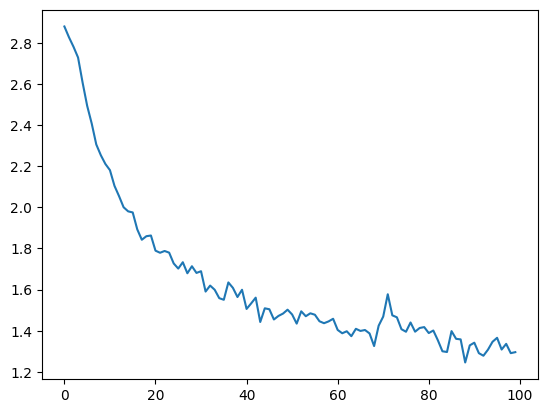

In [28]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure()
plt.plot(all_losses)

## Evaluation des performances
Pour une première évaluation des capacités du réseau on calcule la matrice de confusion.

## **Question 9:** Préciser le rôle de la fonction `evaluate()`
<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    The function receives a name and returns the output of the model, that is, the tensor with the probabilities of each category. it is later used to give the output of multiple examples to construct the confusion matrix.
</div>

## **Question 10:** Quel est le principal défaut de cette évaluation ?
<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    We are not able to see the total accuaracy of the model in the confusion matrix, only the accuaracy of each category. It was implemented in the code a simple counter of right predictions in order to calculate the total accuaracy. The result obtained was low (59.60%).
</div>

## **Question 11:** Quelles sont les langues les moins bien identifiées? Quelles sont les principales confusions ?
<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    The confusion matrix shows that the model presents problems identifing names from categories that share a origin, such as Spanish and Portuguese, or also, English, Irish and Scottish. We can see that the worse accuaracy is seen in English, Czech and German.
</div>


/tmp/ipykernel_64372/1556566354.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + all_categories, rotation=90)
/tmp/ipykernel_64372/1556566354.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + all_categories)


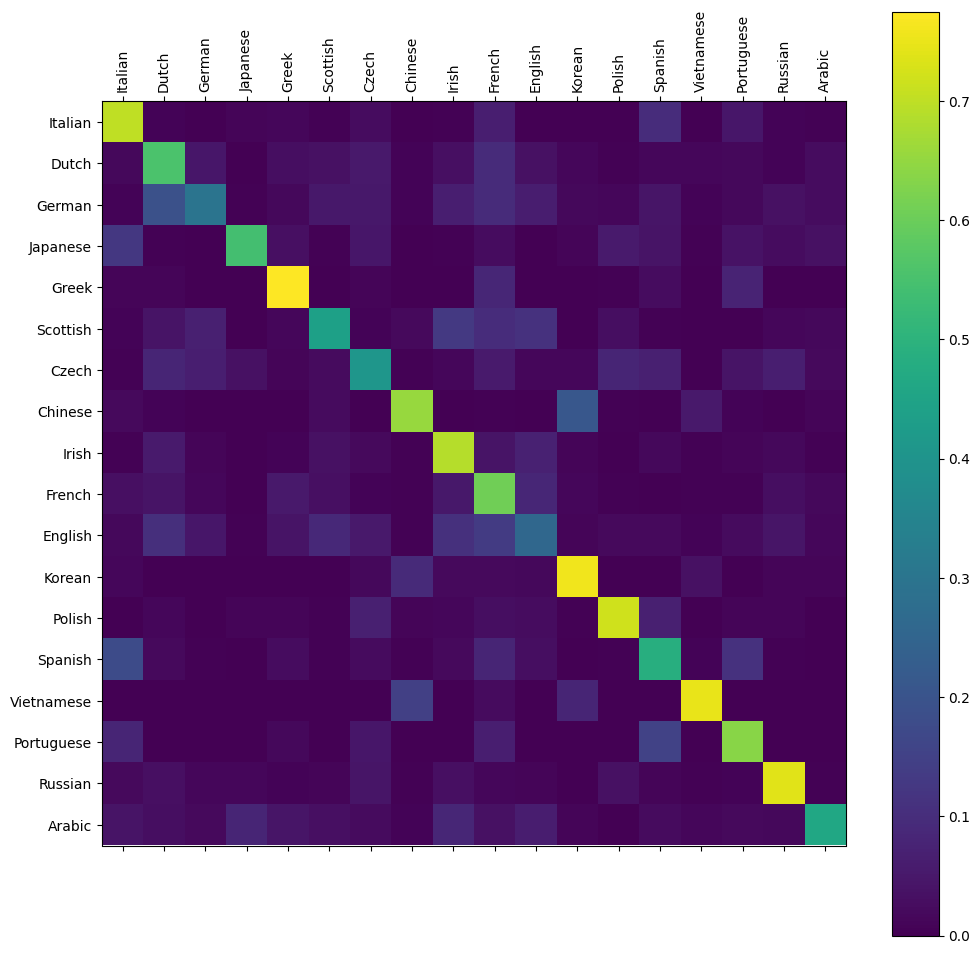

In [29]:
# Keep track of correct guesses in a confusion matrix
confusion = torch.zeros(n_categories, n_categories)
n_confusion = 10000
right_guess = 0

# Just return an output given a line
def evaluate(line_tensor):
    hidden = rnn.initHidden()

    for i in range(line_tensor.size()[0]):
        output, hidden = rnn(line_tensor[i], hidden)

    return output

# Go through a bunch of examples and record which are correctly guessed
for i in range(n_confusion):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    output = evaluate(line_tensor)
    guess, guess_i = categoryFromOutput(output)
    category_i = all_categories.index(category)
    confusion[category_i][guess_i] += 1
    if category_i == guess_i:
      right_guess += 1

# Normalize by dividing every row by its sum
for i in range(n_categories):
    confusion[i] = confusion[i] / confusion[i].sum()

# Set up plot
fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(111)
cax = ax.matshow(confusion.numpy())
fig.colorbar(cax)

# Set up axes
ax.set_xticklabels([''] + all_categories, rotation=90)
ax.set_yticklabels([''] + all_categories)

# Force label at every tick
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

# sphinx_gallery_thumbnail_number = 2
plt.show()

In [30]:
acc = right_guess / n_confusion
print(f"Accuaracy = {acc*100:.2f}%")


Accuaracy = 57.98%


### Exécution sur vos prropres exemples

## **Question 12:** Expliquer les différentes étapes de la méthode `predict()`

In [32]:
def predict(input_line, n_predictions=3): # receives a name and a number of predictions
    print('\n> %s' % input_line)
    with torch.no_grad(): # Disables gradient calculation
        output = evaluate(lineToTensor(input_line)) # getes the probabilities of the name

        # Get top N categories
        topv, topi = output.topk(n_predictions, dim=1, largest=True)
        # largest: controls whether to return largest or smallest elements
        predictions = []

        # prints the probability and the respective class
        for i in range(n_predictions): # for the desired number of predictions
            value = topv[0][i].item() # get the probability
            category_index = topi[0][i].item() # get the category index
            print('(%.2f) %s' % (value, all_categories[category_index]))
            predictions.append([value, all_categories[category_index]])

predict('Rodrigo')
predict('Coelho')
predict('Fernandes')
print("\n Great! The model has identified well my name and surname!")


> Rodrigo
(-0.93) Portuguese
(-1.32) Spanish
(-1.53) Italian

> Coelho
(-0.14) Portuguese
(-3.07) Italian
(-3.17) Spanish

> Fernandes
(-0.35) Portuguese
(-2.09) Spanish
(-2.67) Dutch

 Great! The model has identified well my name and surname!


## Exercices supplémentaires

-  Améliorer les résultats en envisageant une évolution de l'architecture du réseau

   -  ajouter plus de couches linéaires
   -  empiler  plusieurs couches récurrentes
   
-  Extensions possibles : envisager d'autres tâches similaires telles que:
   -  Déduire le genre des prénoms
   -  Classer des lignes de texte parmi Titre / plein texte / légende etc...



In [33]:
import torch.nn as nn

class StackedRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=2):
        super(StackedRNN, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Utilisation d'une LSTM avec plusieurs couches
        self.rnn = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)

        # Ajout de couches linéaires supplémentaires
        self.fc1 = nn.Linear(hidden_size, hidden_size // 2)
        self.fc2 = nn.Linear(hidden_size // 2, output_size)

        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input):
        h0 = torch.zeros(self.num_layers, input.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, input.size(0), self.hidden_size)

        out, _ = self.rnn(input, (h0, c0))

        # Prendre seulement la dernière sortie temporelle
        out = out[:, -1, :]

        # Passer par les couches supplémentaires
        out = torch.relu(self.fc1(out))
        out = self.fc2(out)
        out = self.softmax(out)

        return out

n_hidden = 128
n_layers = 2
model = StackedRNN(n_letters, n_hidden, n_categories, num_layers=n_layers)


5000 5% (0m 10s) 0.3743 Divaev / Russian ✓
10000 10% (0m 21s) 0.7981 Wahner / German ✓
15000 15% (0m 32s) 0.6659 Yang / Chinese ✓
20000 20% (0m 46s) 2.1973 Chijik / Polish ✗ (Russian)
25000 25% (0m 58s) 1.5149 Klemper / German ✗ (Czech)
30000 30% (1m 8s) 1.0699 Yarnall / English ✓
35000 35% (1m 20s) 0.3656 Machado / Portuguese ✓
40000 40% (2m 7s) 0.3721 Safar / Arabic ✓
45000 45% (2m 53s) 1.4055 Nuallan / Scottish ✗ (Irish)
50000 50% (3m 7s) 1.2162 Merlo / Italian ✗ (Spanish)
55000 55% (3m 19s) 2.5728 Jessop / Czech ✗ (English)
60000 60% (3m 31s) 0.1083 Noh / Korean ✓
65000 65% (5m 10s) 0.9308 Como / Italian ✓
70000 70% (6m 13s) 0.7111 Morrison / Scottish ✓
75000 75% (6m 24s) 0.9174 Santos / Portuguese ✓
80000 80% (6m 35s) 0.4380 Bosko / Polish ✓
85000 85% (6m 50s) 1.2953 Snelker / Dutch ✗ (Czech)
90000 90% (7m 0s) 0.0523 Chweh / Korean ✓
95000 95% (7m 12s) 0.2332 Tsangaris / Greek ✓
100000 100% (7m 27s) 4.3563 Jelen / English ✗ (Polish)


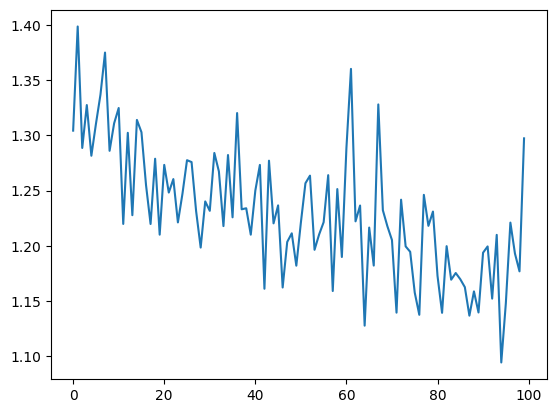

In [34]:
n_iters = 100000
print_every = 5000
plot_every = 1000


# Keep track of losses for plotting
current_loss = 0
all_losses = []

def timeSince(since):
    now = time.time()
    s = now - since
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

start = time.time()

for iter in range(1, n_iters + 1): # loops for i_iter times
    category, line, category_tensor, line_tensor = randomTrainingExample() # selects a random exemple for training
    output, loss = train(category_tensor, line_tensor) # train on that example
    current_loss += loss # updates the loss

    # Print iter number, loss, name and guess periodicaly
    if iter % print_every == 0:
        guess, guess_i = categoryFromOutput(output)
        correct = '✓' if guess == category else '✗ (%s)' % category
        print('%d %d%% (%s) %.4f %s / %s %s' % (iter, iter / n_iters * 100, timeSince(start), loss, line, guess, correct))

    # Add current loss avg to list of losses periodicaly
    if iter % plot_every == 0:
        all_losses.append(current_loss / plot_every)
        current_loss = 0


plt.figure()
plt.plot(all_losses)

/tmp/ipykernel_64372/1556566354.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + all_categories, rotation=90)
/tmp/ipykernel_64372/1556566354.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + all_categories)


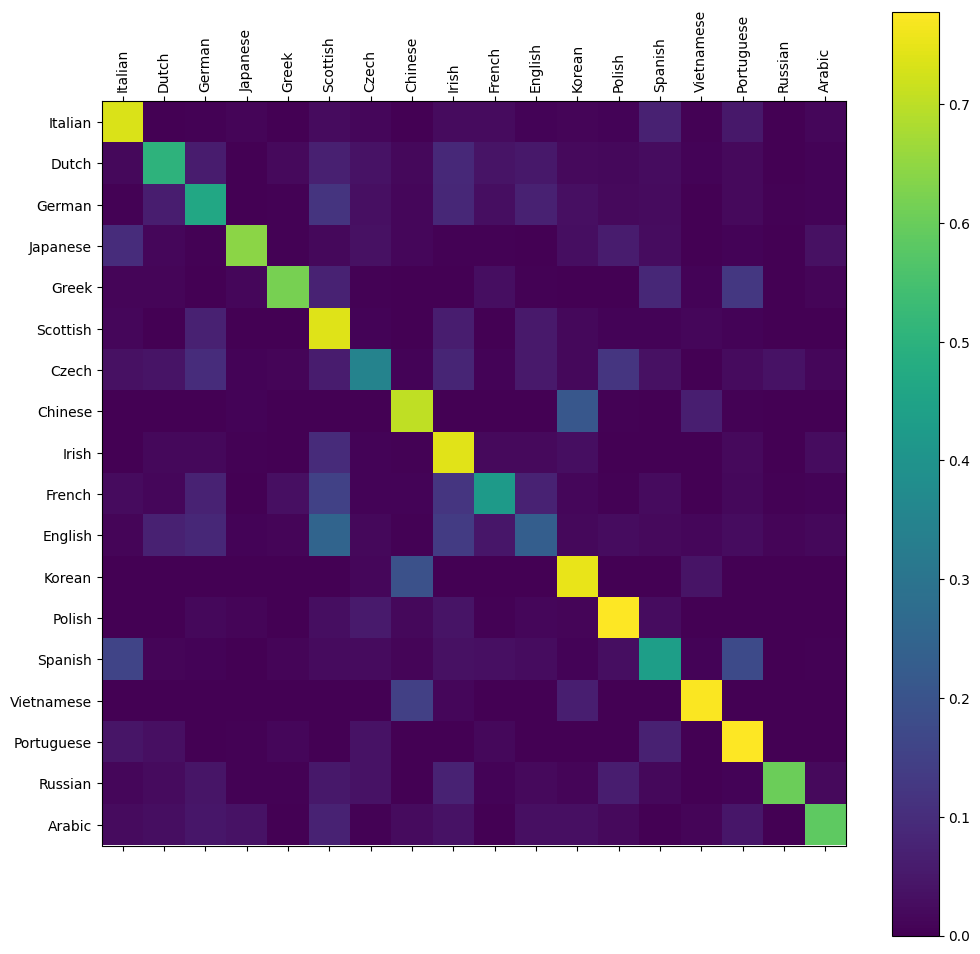

In [35]:
# Keep track of correct guesses in a confusion matrix
confusion = torch.zeros(n_categories, n_categories)
n_confusion = 10000
right_guess = 0

# Just return an output given a line
def evaluate(line_tensor):
    hidden = rnn.initHidden()

    for i in range(line_tensor.size()[0]):
        output, hidden = rnn(line_tensor[i], hidden)

    return output

# Go through a bunch of examples and record which are correctly guessed
for i in range(n_confusion):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    output = evaluate(line_tensor)
    guess, guess_i = categoryFromOutput(output)
    category_i = all_categories.index(category)
    confusion[category_i][guess_i] += 1
    if category_i == guess_i:
      right_guess += 1

# Normalize by dividing every row by its sum
for i in range(n_categories):
    confusion[i] = confusion[i] / confusion[i].sum()

# Set up plot
fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(111)
cax = ax.matshow(confusion.numpy())
fig.colorbar(cax)

# Set up axes
ax.set_xticklabels([''] + all_categories, rotation=90)
ax.set_yticklabels([''] + all_categories)

# Force label at every tick
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

# sphinx_gallery_thumbnail_number = 2
plt.show()

In [36]:
acc = right_guess / n_confusion
print(f"Accuaracy = {acc*100:.2f}%")


Accuaracy = 60.34%
